# SQL y pandas en la Pizzería Don Mario
## Preparación y validación de las bases

In [21]:
from pathlib import Path
import sqlite3
import sys
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from IPython.display import display, Markdown
from don_mario_lab import crear_mini_base, crear_base, CODIGO as CODIGO_MODULO

CODIGO = 2311685
assert CODIGO_MODULO == CODIGO, "Actualizar también CODIGO en don_mario_lab.py"
mini = crear_mini_base()
conn = crear_base(CODIGO, ruta="don_mario.db")
df = pd.read_sql("SELECT * FROM ventas ORDER BY id", mini)
print("Código:", CODIGO)
print("Base de calentamiento:", df.shape)
print("Tipos antes de convertir fecha:")
print(df.dtypes)
df["fecha"] = pd.to_datetime(df["fecha"])
print("Tipo de fecha después:", df["fecha"].dtype)
display(df.head(3))
conteos = pd.DataFrame({
    "tabla": ["clientes", "productos", "ventas"],
    "registros": [conn.execute(f"SELECT COUNT(*) FROM {t}").fetchone()[0]
                  for t in ["clientes", "productos", "ventas"]]
})
display(conteos)
assert df.shape == (20, 5)
assert conteos["registros"].tolist() == [12, 8, 600]
assert conn.execute("PRAGMA integrity_check").fetchone()[0] == "ok"
assert conn.execute("PRAGMA foreign_key_check").fetchall() == []
print("Versiones:", "Python", sys.version.split()[0], "pandas", pd.__version__,
      "SQLite", sqlite3.sqlite_version, "matplotlib", matplotlib.__version__)

Código: 2311685
Base de calentamiento: (20, 5)
Tipos antes de convertir fecha:
id             int64
cliente_id     int64
producto_id    int64
fecha            str
cantidad       int64
dtype: object
Tipo de fecha después: datetime64[us]


,id,cliente_id,producto_id,fecha,cantidad
0,1,1,1,2025-04-01,2
1,2,1,4,2025-04-01,2
2,3,2,2,2025-04-02,1


,tabla,registros
0,clientes,12
1,productos,8
2,ventas,600


Versiones: Python 3.14.3 pandas 3.0.6 SQLite 3.50.4 matplotlib 3.11.2


## Parte 1 Cinco consultas guiadas en SQL

Las cinco consultas se ejecutan sobre `mini`, la base de calentamiento de 20 ventas.
Cada resultado se compara con la cifra indicada en la guía.

In [22]:
# Pregunta 1 — SELECT … WHERE … ORDER BY
# «Lista las pizzas que cuestan más de 28 soles, de cara a barata.»
q1 = """
SELECT nombre, precio
FROM productos
WHERE categoria = 'Pizza' AND precio > 28
ORDER BY precio DESC;
"""
r1 = pd.read_sql(q1, mini)
display(Markdown("### Pregunta 1 Pizzas con precio mayor que S/ 28"))
display(r1)
assert r1["nombre"].tolist() == ["Pizza Pepperoni", "Pizza Hawaiana"]
assert r1["precio"].tolist() == [32.0, 30.0]

# Pregunta 2 — GROUP BY + COUNT
# «¿Cuántas ventas tenemos por categoría de producto?»
q2 = """
SELECT p.categoria, COUNT(*) AS num_ventas
FROM ventas v
JOIN productos p ON v.producto_id = p.id
GROUP BY p.categoria
ORDER BY num_ventas DESC;
"""
r2 = pd.read_sql(q2, mini)
display(Markdown("### Pregunta 2 Ventas por categoría"))
display(r2)
assert dict(zip(r2.categoria, r2.num_ventas)) == {"Pizza": 13, "Bebida": 5, "Postre": 2}
assert r2["num_ventas"].sum() == 20

# Pregunta 3 — GROUP BY + AVG + JOIN
# «¿Cuál es el ticket promedio (gasto por venta) de cada cliente?»
q3 = """
SELECT c.nombre, AVG(p.precio * v.cantidad) AS ticket_promedio
FROM ventas v
JOIN clientes c ON v.cliente_id = c.id
JOIN productos p ON v.producto_id = p.id
GROUP BY c.id, c.nombre
ORDER BY ticket_promedio DESC;
"""
r3 = pd.read_sql(q3, mini)
r3["ticket_promedio"] = r3["ticket_promedio"].round(2)
display(Markdown("### Pregunta 3 Ticket promedio por cliente"))
display(r3)
assert r3["nombre"].tolist() == [
    "Pedro Soto", "María García", "Sofía Ramos", "Ana López", "Luis Pérez"]
assert r3["ticket_promedio"].tolist() == [51.33, 45.0, 33.0, 29.6, 20.25]

# Pregunta 4 — JOIN de 3 tablas
# «Lista cada venta con el nombre del cliente y del producto.»
q4 = """
SELECT v.fecha, c.nombre AS cliente, p.nombre AS producto, v.cantidad
FROM ventas v
JOIN clientes c ON v.cliente_id = c.id
JOIN productos p ON v.producto_id = p.id
ORDER BY v.fecha, v.id;
"""
r4 = pd.read_sql(q4, mini)
display(Markdown("### Pregunta 4 Detalle de las 20 ventas"))
display(r4)
assert len(r4) == 20
assert r4["fecha"].min() == "2025-04-01" and r4["fecha"].max() == "2025-04-17"

# Pregunta 5 — GROUP BY + SUM + ORDER BY + LIMIT
# «Top 3 de productos más vendidos por unidades totales.»
q5 = """
SELECT p.nombre, SUM(v.cantidad) AS unidades
FROM ventas v
JOIN productos p ON v.producto_id = p.id
GROUP BY p.id, p.nombre
ORDER BY unidades DESC
LIMIT 3;
"""
r5 = pd.read_sql(q5, mini)
display(Markdown("### Pregunta 5 Productos más vendidos por unidades"))
display(r5)
assert r5["nombre"].tolist() == [
    "Pizza Margarita", "Pizza Pepperoni", "Inca Kola 500ml"]
assert r5["unidades"].tolist() == [9, 7, 5]
print("Las cinco consultas coinciden con los resultados esperados.")

### Pregunta 1 Pizzas con precio mayor que S/ 28

,nombre,precio
0,Pizza Pepperoni,32.0
1,Pizza Hawaiana,30.0


### Pregunta 2 Ventas por categoría

,categoria,num_ventas
0,Pizza,13
1,Bebida,5
2,Postre,2


### Pregunta 3 Ticket promedio por cliente

...

### Pregunta 4 Detalle de las 20 ventas

,fecha,cliente,producto,cantidad
0,2025-04-01,Ana López,Pizza Margarita,2
1,2025-04-01,Ana López,Coca-Cola 500ml,2
2,2025-04-02,Luis Pérez,Pizza Pepperoni,1
3,2025-04-02,Luis Pérez,Inca Kola 500ml,1
4,2025-04-03,María García,Pizza Hawaiana,1
5,2025-04-03,María García,Tiramisú,2
6,2025-04-05,Ana López,Pizza Pepperoni,1
7,2025-04-05,Pedro Soto,Pizza Margarita,3
8,2025-04-06,Sofía Ramos,Pizza Hawaiana,2
9,2025-04-06,Sofía Ramos,Coca-Cola 500ml,2


### Pregunta 5 Productos más vendidos por unidades

,nombre,unidades
0,Pizza Margarita,9
1,Pizza Pepperoni,7
2,Inca Kola 500ml,5


Las cinco consultas coinciden con los resultados esperados.


## Parte 2 La misma pregunta de dos formas

**Pregunta 6:** ¿Quién gastó más y de qué ciudad es?

Versión A — todo en SQL. El motor devuelve 1 fila.

In [24]:
q6 = """
SELECT c.nombre, c.ciudad, SUM(p.precio * v.cantidad) AS total
FROM ventas v
JOIN clientes c ON v.cliente_id = c.id
JOIN productos p ON v.producto_id = p.id
GROUP BY c.id, c.nombre, c.ciudad
ORDER BY total DESC
LIMIT 1;
"""
version_a = pd.read_sql(q6, mini)

ventas = pd.read_sql("SELECT * FROM ventas", mini)
clientes = pd.read_sql("SELECT * FROM clientes", mini)
productos = pd.read_sql("SELECT * FROM productos", mini)
detalle = (ventas
    .merge(clientes, left_on="cliente_id", right_on="id", suffixes=("", "_c"))
    .merge(productos, left_on="producto_id", right_on="id", suffixes=("", "_p")))
detalle["total"] = detalle["precio"] * detalle["cantidad"]
version_b = (detalle.groupby(["nombre", "ciudad"], as_index=False)["total"]
             .sum().nlargest(1, "total").reset_index(drop=True))

display(Markdown("### Versión A Todo en SQL"))
display(version_a)
display(Markdown("### Versión B Descarga y procesamiento en pandas"))
display(version_b)

filas_a = len(version_a)
filas_b = len(ventas) + len(clientes) + len(productos)
comparacion = pd.DataFrame({
    "versión": ["A SQL", "B pandas"],
    "filas transferidas": [filas_a, filas_b],
    "resultado": [
        f"{version_a.loc[0, 'nombre']}, {version_a.loc[0, 'ciudad']}, S/ {version_a.loc[0, 'total']:.0f}",
        f"{version_b.loc[0, 'nombre']}, {version_b.loc[0, 'ciudad']}, S/ {version_b.loc[0, 'total']:.0f}",
    ]
})
display(comparacion)
assert version_a.round(6).equals(version_b[version_a.columns].round(6))
assert filas_a == 1 and filas_b == 31
assert version_a.loc[0].to_dict() == {
    "nombre": "María García", "ciudad": "Lima", "total": 180.0}
print("Ambas versiones coinciden: María García, Lima, S/ 180.")

### Versión A Todo en SQL

,nombre,ciudad,total
0,María García,Lima,180.0


### Versión B Descarga y procesamiento en pandas

,nombre,ciudad,total
0,María García,Lima,180.0


,versión,filas transferidas,resultado
0,A SQL,1,"María García, Lima, S/ 180"
1,B pandas,31,"María García, Lima, S/ 180"


Ambas versiones coinciden: María García, Lima, S/ 180.


### Reflexión de la Parte 2

1. En la versión A viajó **1 fila**. En la versión B viajaron **31 filas**: 20 de
   ventas, 5 de clientes y 6 de productos.
2. Con 10 millones de ventas, la versión B tendría que transferir aproximadamente
   **10 000 011 filas**, construir dos uniones y conservar los datos intermedios en
   memoria. La demora y el consumo de RAM podrían saturar una laptop. La versión A
   seguiría devolviendo una sola fila agregada.
3. La transferencia se vuelve crítica cuando la tabla es grande, la base está en
   otro servidor, la red tiene poco ancho de banda o latencia alta, o varias personas
   descargan los mismos datos. Si solo se necesita un agregado, conviene calcularlo
   en SQL y transferir el resultado.

## Parte 3 Ventas diarias y promedio móvil

**Pregunta 7:** Grafica las ventas diarias y marca los días por debajo del 80 % del
promedio móvil de 7 días.

Primero SQL suma `precio × cantidad` por fecha. Luego pandas transforma la fecha,
inserta con valor cero los días sin ventas y calcula el promedio móvil. La columna
`ventas` representa ingresos en soles, no el número de registros ni de unidades.

In [25]:
consulta_diaria = """
SELECT v.fecha, SUM(p.precio * v.cantidad) AS ventas
FROM ventas v
JOIN productos p ON v.producto_id = p.id
GROUP BY v.fecha
ORDER BY v.fecha;
"""
diario_sql = pd.read_sql(consulta_diaria, mini)
diario_sql["fecha"] = pd.to_datetime(diario_sql["fecha"])

# Se completa el calendario ANTES de aplicar rolling(7).
diario = diario_sql.set_index("fecha").asfreq("D", fill_value=0)
diario["mm7"] = diario["ventas"].rolling(7, min_periods=4).mean()
diario["umbral_80"] = 0.8 * diario["mm7"]
diario["caida"] = diario["ventas"] < diario["umbral_80"]
display(diario.round(2))

,ventas,mm7,umbral_80,caida
fecha,,,,
2025-04-01,68.0,NaN,NaN,False
2025-04-02,38.0,NaN,NaN,False
2025-04-03,60.0,NaN,NaN,False
2025-04-04,0.0,41.50,33.20,True
2025-04-05,116.0,56.40,45.12,False
2025-04-06,72.0,59.00,47.20,False
2025-04-07,0.0,50.57,40.46,True
2025-04-08,64.0,50.00,40.00,False
2025-04-09,28.0,48.57,38.86,True


### Gráfico y criterio de marcado

La línea azul muestra el ingreso diario; la naranja, el promedio móvil; y la
línea discontinua, el 80 % de ese promedio. Los puntos rojos identifican los días
que cumplen estrictamente `ventas < 0.8 * mm7`.

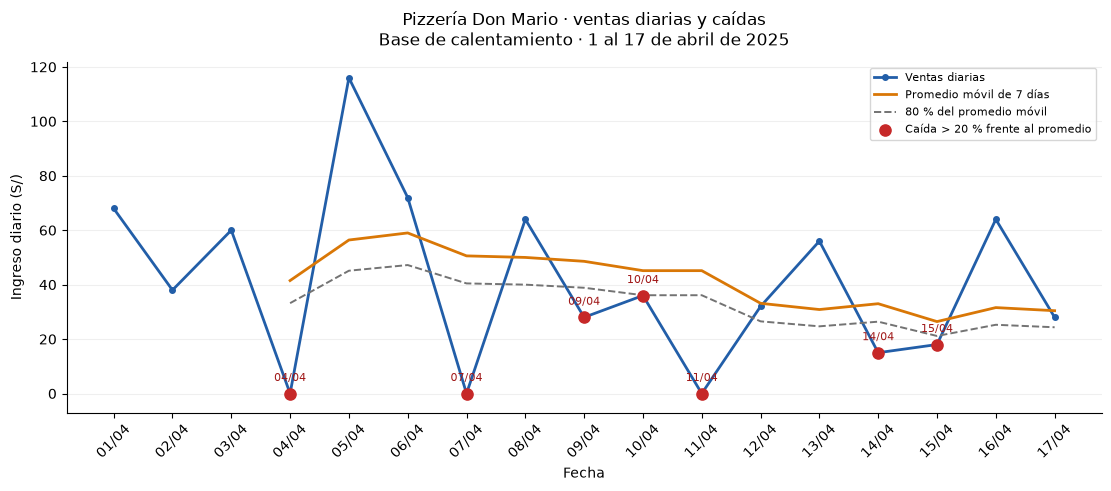

In [26]:
fig, ax = plt.subplots(figsize=(11, 4.8), layout="constrained")
ax.plot(diario.index, diario["ventas"], color="#225ea8", marker="o",
        linewidth=2, markersize=4, label="Ventas diarias")
ax.plot(diario.index, diario["mm7"], color="#d97706", linewidth=2,
        label="Promedio móvil de 7 días")
ax.plot(diario.index, diario["umbral_80"], color="#737373", linewidth=1.4,
        linestyle="--", label="80 % del promedio móvil")
marcados = diario.loc[diario["caida"]]
ax.scatter(marcados.index, marcados["ventas"], color="#c62828", s=65,
           zorder=5, label="Caída > 20 % frente al promedio")
for fecha, fila in marcados.iterrows():
    ax.annotate(fecha.strftime("%d/%m"), (fecha, fila["ventas"]),
                xytext=(0, 9), textcoords="offset points", ha="center",
                fontsize=8, color="#a01818")
ax.set_title("Pizzería Don Mario · ventas diarias y caídas\n"
             "Base de calentamiento · 1 al 17 de abril de 2025", pad=12)
ax.set_xlabel("Fecha")
ax.set_ylabel("Ingreso diario (S/)")
ax.xaxis.set_major_locator(mdates.DayLocator(interval=1))
ax.xaxis.set_major_formatter(mdates.DateFormatter("%d/%m"))
ax.tick_params(axis="x", rotation=45)
ax.set_ylim(bottom=-7)
ax.grid(axis="y", alpha=0.2)
ax.spines[["top", "right"]].set_visible(False)
ax.legend(loc="upper right", fontsize=8)
fig.savefig("ventas_diarias_parte3.png", dpi=180, facecolor="white")
plt.show()

### Comprobación de las métricas de la guía

Se valida la cantidad de días calendario, los días completados con cero y la
cantidad de caídas. También se comprueba que completar el calendario conserve el
ingreso total y que el cálculo manual de cada ventana coincida con pandas.

In [27]:
fechas_sin_ventas = diario.index.difference(diario_sql["fecha"])
resumen = pd.DataFrame([
    ["Ventas en la base de calentamiento", len(df), 20],
    ["Fechas con ventas en SQL", len(diario_sql), 14],
    ["Días calendario", len(diario), 17],
    ["Días sin ventas completados con cero", len(fechas_sin_ventas), 3],
    ["Días marcados", int(diario["caida"].sum()), 7],
], columns=["Métrica", "Obtenido", "Esperado"])
resumen["Cumple"] = resumen["Obtenido"] == resumen["Esperado"]
display(resumen)
assert resumen["Cumple"].all()
assert fechas_sin_ventas.strftime("%Y-%m-%d").tolist() == [
    "2025-04-04", "2025-04-07", "2025-04-11"]
assert diario.index.min() == pd.Timestamp("2025-04-01")
assert diario.index.max() == pd.Timestamp("2025-04-17")
assert diario["ventas"].sum() == diario_sql["ventas"].sum()
for i in range(len(diario)):
    ventana = diario["ventas"].iloc[max(0, i-6):i+1]
    if len(ventana) < 4:
        assert pd.isna(diario["mm7"].iloc[i])
    else:
        assert abs(diario["mm7"].iloc[i] - ventana.mean()) < 1e-9
print("Días sin ventas:", ", ".join(fechas_sin_ventas.strftime("%d/%m/%Y")))
print("Días marcados:", ", ".join(marcados.index.strftime("%d/%m/%Y")))
print("Ingreso total de la base de calentamiento: S/", diario["ventas"].sum())
print("Comprobaciones superadas.")
display(marcados[["ventas", "mm7", "umbral_80"]].round(2))

,Métrica,Obtenido,Esperado,Cumple
0,Ventas en la base de calentamiento,20,20,True
1,Fechas con ventas en SQL,14,14,True
2,Días calendario,17,17,True
3,Días sin ventas completados con cero,3,3,True
4,Días marcados,7,7,True


Días sin ventas: 04/04/2025, 07/04/2025, 11/04/2025
Días marcados: 04/04/2025, 07/04/2025, 09/04/2025, 10/04/2025, 11/04/2025, 14/04/2025, 15/04/2025
Ingreso total de la base de calentamiento: S/ 695.0
Comprobaciones superadas.


,ventas,mm7,umbral_80
fecha,,,
2025-04-04,0.0,41.50,33.20
2025-04-07,0.0,50.57,40.46
2025-04-09,28.0,48.57,38.86
2025-04-10,36.0,45.14,36.11
2025-04-11,0.0,45.14,36.11
2025-04-14,15.0,33.00,26.40
2025-04-15,18.0,26.43,21.14


### Interpretación del resultado

`rolling(7)` cuenta siete filas. Al completar primero el calendario con `asfreq("D", fill_value=0)`,
cada fila representa un día consecutivo y la ventana abarca una semana. Si se
omitiera ese paso, las siete últimas fechas con ventas podrían abarcar más de siete
días y excluirían los días de ingreso cero.

`min_periods=4` exige cuatro observaciones para calcular el promedio. Por eso los
días 1, 2 y 3 de abril tienen `mm7 = NaN` y no se marcan. Del 4 al 6 de abril se
usa la historia disponible; desde el 7 de abril se dispone de una ventana completa.
El promedio incluye el día evaluado, exactamente como indica la guía.

Una marca roja significa que el ingreso está más de un 20 % por debajo del promedio
de la ventana; no significa una caída de más del 20 % respecto al día anterior.
Esta condición puede servir como señal para un agente reflejo, aunque por sí sola
no demuestra que una promoción sea rentable.

## Parte 4 Tabla de decisión

| Tarea | ¿Dónde la harías? | ¿Por qué? |
|---|---|---|
| Filtrar 50 M de filas por rango de fecha | SQL | El motor filtra en origen y puede aprovechar un índice en fecha; se transfieren solo las filas necesarias. |
| Sumar ventas por sucursal | SQL | `GROUP BY` y `SUM` calculan el agregado dentro de la base y devuelven una fila por sucursal. |
| Graficar una serie temporal con anotaciones | pandas | Organiza y transforma la serie; se combina con Matplotlib para dibujar líneas, marcas y anotaciones. |
| Unir 4 tablas relacionales | SQL | `JOIN` relaciona las tablas por sus claves antes de transferir el resultado; el motor puede aprovechar índices. |
| Aplicar RandomForestClassifier | pandas | Permite preparar variables, tratar faltantes y separar características y etiqueta; el clasificador se entrena con scikit-learn. |
| Promedio móvil de 30 días | pandas | Un índice de fechas facilita `rolling("30D")`; para incluir días sin ventas con cero, se completa antes el calendario y se usa `rolling(30)`. |
| Contar registros únicos | SQL | `COUNT(DISTINCT columna)` devuelve el conteo sin descargar todos los registros; para combinaciones de columnas, se usa una subconsulta `SELECT DISTINCT`. |
| Pivotar una tabla larga a ancha y rellenar NaN con 0 | pandas | `pivot_table(..., fill_value=0)` reorganiza los datos y rellena las combinaciones sin valor; `fillna(0)` también permite completar faltantes. |

Las elecciones corresponden a estas tareas y al volumen de datos descrito. SQL
también puede calcular ventanas móviles, y pandas puede filtrar y unir tablas; la
decisión depende de cuánto se necesita transferir y de la transformación posterior.

In [20]:
mini.close()
conn.close()
print("Bases cerradas. Archivos generados: don_mario.db y ventas_diarias_parte3.png")

Bases cerradas. Archivos generados: don_mario.db y ventas_diarias_parte3.png
